# Alineamientos Globales en la ONU (2010–2024) – Clusterización de Votos

## Introducción

Las votaciones en la Asamblea General de las Naciones Unidas (ONU) son un indicador privilegiado para comprender la **política internacional contemporánea**, ya que ponen en evidencia alianzas, tensiones geopolíticas y posicionamientos sobre los principales temas de la agenda global.

Este proyecto analiza **cómo se agrupan los países** en función de sus patrones de voto en la Asamblea General durante el período **2010–2024**, tomando en consideración resoluciones en las que los Estados debieron pronunciarse mediante las opciones:

- **Yes**
- **No**
- **Abstain**

El propósito central es **identificar bloques de alineamiento internacional** surgidos a partir de los datos, sin imponer categorías geopolíticas a priori.

---

En este análisis se aplican **técnicas de Machine Learning no supervisado** para descubrir patrones en las preferencias de votación. Particularmente, se emplean:

- Transformación numérica de votos (Yes = 1, Abstain = 0.5, No = 0)  
- **Cosine Similarity** para medir cercanía entre países  
- **PCA** para reducir dimensionalidad y visualizar alineamientos  
- **K-Means** para identificar clusters  
- **Visualizaciones** como heatmaps, dendrogramas y mapas interactivos

El foco politológico se orienta a examinar la dinámica de alianzas entre potencias globales, bloques regionales y países con posiciones intermedias o fluctuantes.

---

**Dataset utilizado**
- UN General Assembly Voting Data — Kaggle  
- País–resolución–año con votaciones registradas  
- Subconjunto: **2010–2024** para capturar alineamientos recientes  

---

## Preguntas guía

- ¿Qué **bloques internacionales** emergen de las votaciones más recientes?  
- ¿Cómo se posicionan países clave como Argentina, Brasil, India o Sudáfrica?  
- ¿Qué temas generan mayor **divergencia** entre bloques?  

---

## Objetivos

- Identificar **agrupamientos empíricos** basados en patrones de voto.  
- Analizar **distancias geopolíticas** entre Estados mediante similitud del voto.  
- Visualizar bloques y **áreas de cooperación/conflicto** en la política mundial.  
- Evaluar el **rol regional** y la posición relativa de América Latina.  

---

## Alcance y supuestos

- Se consideran las votaciones disponibles en el período 2010–2024.  
- La abstención se conceptualiza como un voto intermedio (**0.5**).  
- Los clusters identificados son **aproximaciones analíticas** que simplifican la complejidad internacional.  

---

## Reproducibilidad

- Dependencias definidas en `requirements.txt`  
- Proyecto estructurado según buenas prácticas de Data Science  
- Código y figuras disponibles en GitHub  

## 0. Configuración inicial

En esta sección se importan las librerías necesarias y se definen configuraciones visuales globales que se utilizarán a lo largo del análisis.

In [2]:
# --- Importaciones principales ---
import pandas as pd
import numpy as np

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# (Kaleido se utiliza en segundo plano para exportar figuras estáticas)

# --- Métricas de similitud ---
from sklearn.metrics.pairwise import cosine_similarity

# --- Reducción de dimensionalidad ---
from sklearn.decomposition import PCA

# --- Clustering ---
from sklearn.cluster import KMeans

# --- Evaluación del clustering ---
from sklearn.metrics import silhouette_score

# --- Información geográfica ---
import pycountry
import pycountry_convert

In [ ]:
# --- Configuración visual unificada ---

# Estilo de gráficos y paleta de colores
sns.set(style="whitegrid")
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

# Tamaño por defecto de las figuras
plt.rcParams['figure.figsize'] = (10, 6)

# Ver todas las columnas en inspección de DataFrames
pd.set_option('display.max_columns', None)

## 1. Carga e inspección inicial de los datos

En esta sección se carga el dataset y se realiza una primera exploración general. El objetivo es verificar la estructura, tipos de datos, valores nulos o duplicados, y obtener una visión preliminar del contenido antes del análisis detallado.

In [3]:
# --- Carga de datos ---
file_path = "data/raw/un_votes_raw.csv"
df = pd.read_csv(file_path, low_memory=False)

In [7]:
# --- Vista general y estructura ---
print("Dimensiones:", df.shape)
display(df.head())
print("\nInformación general del DataFrame:\n")
df.info()

Dimensiones: (7855, 270)


,Council,Date,Title,Resolution,TOTAL VOTES,NO-VOTE COUNT,ABSENT COUNT,NO COUNT,YES COUNT,Link,...,BOLIVIA (PLUNATIONAL STATE OF),SIAM,REPULIC OF MOLDOVA,PHILIPPINE REPUBLIC,SURINAM,BELGIUM,SAINT CHRISTOPHER AND NEVIS,TKAZAKHSTAN,DEMOCRATIC CAMPUCHEA,CONGO (DEMOCRATIC REPUBLIC OF)
0,Security Council,2016-12-13,Security Council resolution 2323 (2016) [on ex...,S/RES/2323(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852025?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Security Council,2020-06-22,Security Council resolution 2527 (2020) [on ex...,S/RES/2527(2020),15,0,0,0,15,https://digitallibrary.un.org/record/3866679?l...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Security Council,2016-12-14,Security Council resolution 2324 (2016) [on Se...,S/RES/2324(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852028?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Security Council,2016-12-12,Security Council resolution 2322 (2016) [on in...,S/RES/2322(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852020?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Security Council,2005-09-23,Security Council resolution 1627 (2005) [on ex...,S/RES/1627(2005),15,0,0,0,15,https://digitallibrary.un.org/record/557118?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Información general del DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7855 entries, 0 to 7854
Columns: 270 entries, Council to CONGO (DEMOCRATIC REPUBLIC OF)
dtypes: int64(6), object(264)
memory usage: 16.2+ MB


In [15]:
# --- Conversión de fecha a datetime y extracción de año ---
df.loc[:, 'Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.loc[:, 'year'] = df['Date'].dt.year

# --- Eliminación de registros sin fecha válida ---
df = df[df['year'].notna()].copy()
df.loc[:, 'year'] = df['year'].astype(int)

# --- Verificación de cobertura temporal ---
print("Años disponibles en el dataset:")
print(sorted(df['year'].unique()))

print("\nCantidad de votos por año:")
display(df['year'].value_counts().sort_index())

Años disponibles en el dataset:
[1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

Cantidad de votos por año:


year
1946     41
1947     35
1948     45
1949     29
1950     29
       ... 
2017    155
2018    163
2019    152
2020    157
2021    145
Name: count, Length: 76, dtype: int64

In [14]:
# --- Conversión de fecha a datetime y extracción de año ---
df.loc[:, 'Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.loc[:, 'year'] = df['Date'].dt.year

# --- Eliminación de registros sin fecha válida ---
df = df[df['year'].notna()].copy()  # <-- ¡clave!
df.loc[:, 'year'] = df['year'].astype(int)
print("\nCantidad de votos por año:")


Cantidad de votos por año:


### 1.1 Selección del período de análisis (2010–2024)

Se selecciona el período 2010–2024 por ser lo suficientemente reciente como para reflejar 
la actualidad geopolítica y lo suficientemente amplio como para mitigar variaciones temáticas 
puntuales en las resoluciones anuales de la Asamblea General de la ONU.

In [16]:
# --- Filtrado por período de análisis ---
df = df[(df['year'] >= 2010) & (df['year'] <= 2024)].copy()

print("Nuevas dimensiones:", df.shape)
display(df.head())

Nuevas dimensiones: (1718, 271)


,Council,Date,Title,Resolution,TOTAL VOTES,NO-VOTE COUNT,ABSENT COUNT,NO COUNT,YES COUNT,Link,...,SIAM,REPULIC OF MOLDOVA,PHILIPPINE REPUBLIC,SURINAM,BELGIUM,SAINT CHRISTOPHER AND NEVIS,TKAZAKHSTAN,DEMOCRATIC CAMPUCHEA,CONGO (DEMOCRATIC REPUBLIC OF),year
0,Security Council,2016-12-13,Security Council resolution 2323 (2016) [on ex...,S/RES/2323(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852025?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016
1,Security Council,2020-06-22,Security Council resolution 2527 (2020) [on ex...,S/RES/2527(2020),15,0,0,0,15,https://digitallibrary.un.org/record/3866679?l...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
2,Security Council,2016-12-14,Security Council resolution 2324 (2016) [on Se...,S/RES/2324(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852028?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016
3,Security Council,2016-12-12,Security Council resolution 2322 (2016) [on in...,S/RES/2322(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852020?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016
5,General Assembly,2021-12-06,Reducing nuclear danger : resolution / adopted...,A/RES/76/27,193,4,14,50,125,https://digitallibrary.un.org/record/3950570?l...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021


In [17]:
# --- Calidad de datos ---

# Valores nulos por columna (top 10)
nulos = df.isnull().sum().sort_values(ascending=False)
print("Top 10 columnas con mayor cantidad de valores nulos (%):\n")
nulos_pct = (nulos / len(df)) * 100
print(nulos_pct.head(10).round(2).to_string())

# Filas duplicadas exactas
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}")

Top 10 columnas con mayor cantidad de valores nulos (%):

 ALGERIA                100.0
BURMA                   100.0
SYRIA                   100.0
SERBIAMONTENEGRO        100.0
DAHOMEY                 100.0
CEYLON                  100.0
LAOS                    100.0
KHMER REPUBLIC          100.0
IRAN                    100.0
LIBYAN ARAB REPUBLIC    100.0

Filas duplicadas: 0


In [19]:
# Inspección inicial para comprender la estructura del dataset
display(df.head())
df.columns.tolist()

,Council,Date,Title,Resolution,TOTAL VOTES,NO-VOTE COUNT,ABSENT COUNT,NO COUNT,YES COUNT,Link,...,SIAM,REPULIC OF MOLDOVA,PHILIPPINE REPUBLIC,SURINAM,BELGIUM,SAINT CHRISTOPHER AND NEVIS,TKAZAKHSTAN,DEMOCRATIC CAMPUCHEA,CONGO (DEMOCRATIC REPUBLIC OF),year
0,Security Council,2016-12-13,Security Council resolution 2323 (2016) [on ex...,S/RES/2323(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852025?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016
1,Security Council,2020-06-22,Security Council resolution 2527 (2020) [on ex...,S/RES/2527(2020),15,0,0,0,15,https://digitallibrary.un.org/record/3866679?l...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
2,Security Council,2016-12-14,Security Council resolution 2324 (2016) [on Se...,S/RES/2324(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852028?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016
3,Security Council,2016-12-12,Security Council resolution 2322 (2016) [on in...,S/RES/2322(2016),15,0,0,0,15,https://digitallibrary.un.org/record/852020?ln=en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016
5,General Assembly,2021-12-06,Reducing nuclear danger : resolution / adopted...,A/RES/76/27,193,4,14,50,125,https://digitallibrary.un.org/record/3950570?l...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021


['Council',
 'Date',
 'Title',
 'Resolution',
 'TOTAL VOTES',
 'NO-VOTE COUNT',
 'ABSENT COUNT',
 'NO COUNT',
 'YES COUNT',
 'Link',
 'token',
 'SENEGAL',
 'MALAYSIA',
 'VENEZUELA (BOLIVARIAN REPUBLIC OF)',
 'UNITED KINGDOM',
 'RUSSIAN FEDERATION',
 'JAPAN',
 'ANGOLA',
 'URUGUAY',
 'SPAIN',
 'EGYPT',
 'NEW ZEALAND',
 'UNITED STATES',
 'FRANCE',
 'CHINA',
 'UKRAINE',
 'NIGER',
 'SAINT VINCENT AND THE GRENADINES',
 'ESTONIA',
 'SOUTH AFRICA',
 'VIET NAM',
 'BELGIUM',
 'GERMANY',
 'TUNISIA',
 'INDONESIA',
 'DOMINICAN REPUBLIC',
 'BRAZIL',
 'UNITED REPUBLIC OF TANZANIA',
 'PHILIPPINES',
 'ALGERIA',
 'BENIN',
 'DENMARK',
 'ROMANIA',
 'ARGENTINA',
 'GREECE',
 'AUSTRIA',
 'SWITZERLAND',
 'CYPRUS',
 'MOZAMBIQUE',
 'SUDAN',
 'FIJI',
 'BULGARIA',
 'CUBA',
 'UGANDA',
 'ZAMBIA',
 'SOUTH SUDAN',
 'MONACO',
 'REPUBLIC OF KOREA',
 'REPUBLIC OF MOLDOVA',
 'SAN MARINO',
 'YEMEN',
 'ITALY',
 'BURUNDI',
 'HUNGARY',
 'CAMBODIA',
 'MALAWI',
 'NAURU',
 'NICARAGUA',
 'BRUNEI DARUSSALAM',
 'POLAND',
 'THAILAN

### 1.2 Transformación del dataset a formato país–resolución

El dataset original presenta los votos en formato **wide**, donde cada país aparece como una columna distinta. Esta estructura dificulta el análisis con técnicas de Machine Learning que requieren que cada observación esté en una fila diferente.

Se convierte el dataset a formato **long**, de modo que cada fila represente:

- un país
- una resolución de la Asamblea General
- un voto asociado
- el año en que se realizó la votación

Esto permite construir una matriz país–resolución adecuada para:

✅ cálculo de **distancias de similitud** (Cosine Similarity)  
✅ **PCA** para reducción de dimensionalidad  
✅ **clustering** para identificar alineamientos internacionales  
✅ visualizaciones comparativas entre países

Esta transformación es estándar en estudios sobre patrones de votación en la ONU utilizando aprendizaje automático.

In [28]:
# --- Selección de datos de la Asamblea General ---
df_ga = df[df['Council'] == "General Assembly"].copy()

# Columnas de países: todas las columnas después de la metadata (inicio en la posición 11)
country_cols = df_ga.columns.tolist()[11:]

# --- Transformación wide -> long ---
df_long = df_ga.melt(
    id_vars=['Date', 'year', 'Resolution'], 
    value_vars=country_cols,
    var_name='country',
    value_name='vote'
)

print("Dimensiones del dataset transformado:", df_long.shape)
display(df_long.head())

Dimensiones del dataset transformado: (261072, 5)


,Date,year,Resolution,country,vote
0,2021-12-06,2021,A/RES/76/27,SENEGAL,Y
1,2021-12-06,2021,A/RES/76/26,SENEGAL,Y
2,2021-12-06,2021,A/RES/76/29,SENEGAL,Y
3,2021-12-06,2021,A/RES/76/20,SENEGAL,Y
4,2021-12-06,2021,A/RES/76/21,SENEGAL,Y


### 1.3 Análisis y codificación de los votos

Antes de aplicar técnicas de Machine Learning es necesario transformar los valores de voto en una representación numérica. Para ello, primero se inspeccionan los valores únicos presentes en la columna `vote`.

In [29]:
# Verificación de categorías en la columna 'vote'
df_long['vote'].value_counts()

vote
Y    145129
A     20970
X     15647
N     12721
Name: count, dtype: int64

Los votos en la Asamblea General de la ONU se registran con cuatro códigos:

| Código | Significado | Interpretación política |
|--------|-------------|-----------------------|
| Y | Yes (A favor) | Apoyo explícito a la resolución |
| A | Abstain (Abstención) | Posición intermedia / ambigua |
| N | No (En contra) | Rechazo directo |
| X | Absent / Not Voting | Ausencia (no expresa posición política) |

Para el análisis de similitud entre países se requiere una representación cuantitativa. 
Se asignan valores numéricos utilizados comúnmente en estudios de votación en la ONU:

- **Y → 1.0** (alineamiento)
- **A → 0.5** (neutralidad relativa)
- **N → 0.0** (desalineamiento)
- **X → NaN** (sin señal política → dato faltante)

> Nota metodológica: La distinción ordinal entre Y, A y N, así como el tratamiento de la 
> ausencia de voto como falta de señal política, está respaldada en la literatura sobre 
> votación en la ONU (Voeten, 2012).

In [36]:
# --- Codificación de votos ---
vote_map = {
    'Y': 1.0,   # Yes
   'A': 0.5,   # Abstain
    'N': 0.0,   # No
    'X': np.nan # Absent / Not voting (se trata como dato faltante)
}

df_long['vote_num'] = df_long['vote'].map(vote_map)

# Verificación de la codificación
display(df_long[['vote', 'vote_num']].head())
print("Valores únicos en 'vote_num':", df_long['vote_num'].unique().tolist())

,vote,vote_num
0,Y,1.0
1,Y,1.0
2,Y,1.0
3,Y,1.0
4,Y,1.0


Valores únicos en 'vote_num': [1.0, 0.5, nan, 0.0]


#### ✅ Conclusiones de la inspección inicial

- El dataset original presenta los votos en **formato wide**, donde cada país aparece como una columna  
  → Se transformó a **formato long** para que cada fila represente un país–resolución–voto  
- Se seleccionaron los datos de la **Asamblea General** en el período **2010–2024**, que refleja la geopolítica contemporánea
- Se prepararon y codificaron los tipos de voto utilizando una escala cuantitativa estándar para el análisis comparado:

  | Voto | Valor | Interpretación en ML |
  |------|:----:|--------------------|
  | Yes | 1.0 | Alineamiento con la resolución |
  | Abstain | 0.5 | Neutralidad relativa |
  | No | 0.0 | Oposición |
  | Absent | NaN | Sin señal política |

- Los valores faltantes se mantienen como **NaN**, ya que la ausencia de voto no implica una posición política  
- Tras el preprocesamiento, el dataset se encuentra preparado para:
  ✅ construir la matriz país–resolución  
  ✅ calcular **similitudes** entre países  
  ✅ aplicar **PCA** y técnicas de **clustering** no supervisado

## 2. Preparación del dataset para clustering

La representación país–resolución permite analizar alineamientos internacionales mediante
su comportamiento de voto en la Asamblea General de la ONU.

El objetivo de esta sección es:
- construir una **matriz país–resolución** con valores de voto numéricos
- evaluar la **cobertura de participación** por país
- definir un **umbral mínimo aceptable** para asegurar calidad del clustering


### 2.1 Construcción de la matriz país–resolución

Se transforma el dataset a un formato matricial en el que cada país es representado por su patrón de votación frente a cada resolución. Esta estructura es necesaria para aplicar medidas de similitud y técnicas de clustering en las siguientes etapas del análisis.


In [52]:
# --- Construcción de la matriz país–resolución ---
# Cada fila representa un país y cada columna una resolución.
# Los valores corresponden a la codificación numérica del voto (1=Yes, 0.5=Abstain, 0=No, NaN=Ausente).

votes_matrix = df_long.pivot_table(
    values='vote_num',
    index='country',
    columns='Resolution'
)

print("Dimensiones de la matriz país–resolución:", votes_matrix.shape)
votes_matrix.head()

Dimensiones de la matriz país–resolución: (201, 1007)


Resolution,A/73/L.42,A/76/L.14,A/RES/64/254,A/RES/64/282,A/RES/64/292,A/RES/64/296,A/RES/65/100,A/RES/65/101,A/RES/65/102,A/RES/65/103,...,A/RES/76/79,A/RES/76/80,A/RES/76/81,A/RES/76/82,A/RES/76/85,A/RES/76/86,A/RES/76/87,A/RES/ES-10/19,A/RES/ES-10/20,MISSING_DATA
country,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0.5,1.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ALBANIA,1.0,1.0,0.5,1.0,NaN,1.0,1.0,1.0,0.5,1.0,...,1.0,0.5,1.0,1.0,1.0,1.0,0.5,1.0,0.5,0.5
ALGERIA,0.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ANDORRA,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,...,1.0,0.5,1.0,1.0,1.0,1.0,0.5,1.0,1.0,0.5
ANGOLA,0.5,1.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 2.2 Cobertura de participación por país

Se calcula el porcentaje de votaciones en las que cada país emitió una posición (Yes / No / Abstain). La ausencia (X) se considera dato faltante y reduce cobertura.


Estadísticas de participación por país (%):


count    201.00
mean      88.26
std       19.85
min        0.10
25%       87.19
50%       97.12
75%       99.40
max      100.00
dtype: float64

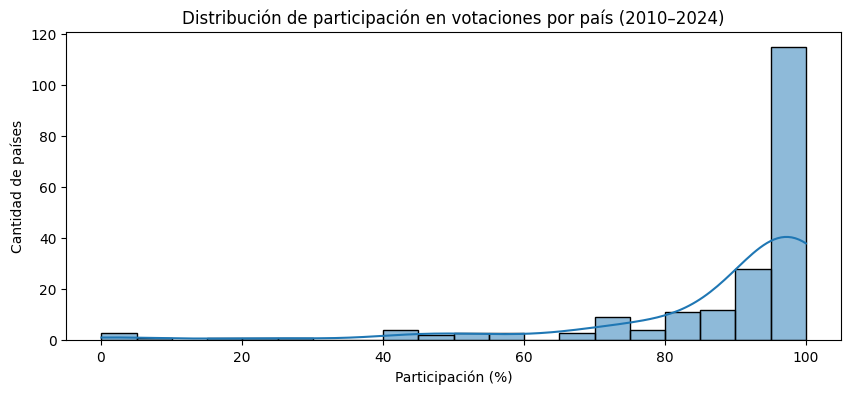

In [58]:
# --- Cobertura de participación por país ---
# Mayor proporción de NaNs = menor participación en votaciones → posible efecto negativo en el clustering

missing_by_country = (votes_matrix.isnull().mean(axis=1) * 100).round(2)
coverage = 100 - missing_by_country  # participación efectiva por país (%)

print("Estadísticas de participación por país (%):")
display(coverage.describe().round(2))

# Distribución visual
plt.figure(figsize=(10,4))
sns.histplot(coverage, bins=20, kde=True)
plt.title("Distribución de participación en votaciones por país (2010–2024)")
plt.xlabel("Participación (%)")
plt.ylabel("Cantidad de países")
plt.show()

### 2.3 Criterio de cobertura mínima para el análisis

Se establece un umbral mínimo del **70% de participación** en votaciones (2010–2024). Los países por debajo se excluyen por poseer señal política incompleta que puede distorsionar el clustering.


In [54]:
# --- Filtro mínimo de participación ---
umbral = 70

countries_selected = coverage[coverage >= umbral].index
votes_matrix_filtered = votes_matrix.loc[countries_selected].copy()

print(f"Países retenidos: {len(countries_selected)}")
print(f"Países excluidos: {votes_matrix.shape[0] - len(countries_selected)}")

Países retenidos: 179
Países excluidos: 22


In [56]:
for umbral in [50, 60, 70, 80, 90]:
    retained = (coverage >= umbral).sum()
    print(f"Umbral {umbral}% → Países retenidos: {retained}")

Umbral 50% → Países retenidos: 188
Umbral 60% → Países retenidos: 182
Umbral 70% → Países retenidos: 179
Umbral 80% → Países retenidos: 166
Umbral 90% → Países retenidos: 143


#### ✅ Conclusiones de calidad de datos y cobertura (2010–2024)

A partir de la matriz país–resolución se evaluó la participación de cada Estado en las
votaciones de la Asamblea General. Se analizaron distintos umbrales mínimos de cobertura:

| Umbral de participación | Países retenidos | Países excluidos |
|-----------------------:|----------------:|----------------:|
| ≥ 50% | 188 | 13 |
| ≥ 60% | 182 | 19 |
| ✅ ≥ 70% | 179 | 22 |
| ≥ 80% | 166 | 35 |
| ≥ 90% | 143 | 58 |

El criterio seleccionado (**≥ 70%**) equilibra dos aspectos:

1️⃣ **Representatividad global** → mantiene 179 países con señal política consistente  
2️⃣ **Calidad del clustering** → elimina casos con votación demasiado incompleta que
    pueden distorsionar medidas de similitud

Con este filtrado, se avanza hacia la construcción de la matriz final que se empleará
en la reducción de dimensionalidad y el modelado de clustering.

## 3. Manejo de valores faltantes

En la matriz país–resolución persisten valores faltantes asociados a ausencias o no participación
en determinadas votaciones. Para poder aplicar técnicas de similitud, reducción de dimensionalidad
y clustering, es necesario completar estos valores.

En esta sección se evalúa la cobertura por resolución y se establecen criterios de imputación que
mantengan la validez política y estadística del análisis.

### 3.1 Evaluación de cobertura por resolución

Además de la participación por país, es necesario verificar la cobertura de votación por resolución.
Las resoluciones con una participación muy baja aportan una señal política incompleta y pueden introducir ruido en las medidas de similitud entre países.

En esta etapa se analiza qué porcentaje de países votó cada resolución para definir un umbral mínimo que permita excluir aquellas con escasa representación global.


Estadísticas de participación por resolución (%):


count    1007.00
mean       94.22
std         6.31
min        47.49
25%        93.85
50%        96.09
75%        97.77
max       100.00
dtype: float64

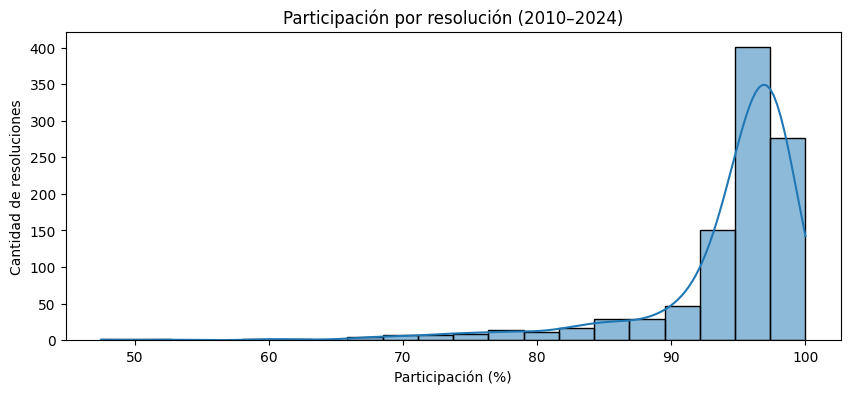

In [ ]:
# --- Cobertura por resolución ---
missing_by_resolution = (votes_matrix_filtered.isnull().mean() * 100).round(2)
coverage_res = 100 - missing_by_resolution  # % de países que votaron cada resolución

print("Estadísticas de participación por resolución (%):")
display(coverage_res.describe().round(2))

# Visualización
plt.figure(figsize=(10,4))
sns.histplot(coverage_res, bins=20, kde=True)
plt.title("Participación por resolución (2010–2024)")
plt.xlabel("Participación (%)")
plt.ylabel("Cantidad de resoluciones")
plt.show()

### 3.2 Selección de resoluciones para el análisis

Se observa que la gran mayoría de las resoluciones presentan una participación superior al 90%.
Para evitar columnas con señal política incompleta, se excluyen aquellas con una participación
menor al **80%**.

Este umbral permite mantener la representatividad global del comportamiento de voto sin
incorporar ruido en el cálculo de similitudes entre países.

In [60]:
# --- Filtro mínimo de cobertura por resolución ---
umbral_res = 80

resolutions_selected = coverage_res[coverage_res >= umbral_res].index
votes_matrix_filtered = votes_matrix_filtered[resolutions_selected].copy()

print(f"Resoluciones retenidas: {len(resolutions_selected)}")
print(f"Resoluciones excluidas: {votes_matrix_filtered.shape[1] - len(resolutions_selected)}")

Resoluciones retenidas: 957
Resoluciones excluidas: 0


✅ Conclusión sobre cobertura por resolución

La gran mayoría de las resoluciones presentan una participación global muy alta. La mediana se ubica en **96%** y el 75% de las resoluciones supera el **93,8%** de participación. Solo un grupo reducido cae por debajo del 80%.

No fue necesario excluir resoluciones adicionales, manteniendo así una matriz país–resolución con una señal política fuerte y ampliamente representativa del comportamiento de voto.


### 3.3 Imputación de valores faltantes

Las ausencias en las votaciones se representan con NaN, lo que impide el cálculo de similitudes y la aplicación de PCA. Para completar la matriz país–resolución se adopta una imputación basada en el **promedio del propio país** en el período analizado.

Este criterio preserva el patrón geopolítico agregado de cada Estado sin introducir información externa ni sesgos temáticos, manteniendo la coherencia de la estructura latente de alineamientos internacionales.


In [61]:
# --- Imputación: media por país ---
votes_matrix_imputed = votes_matrix_filtered.apply(
    lambda row: row.fillna(row.mean()), axis=1
)

print("NaNs restantes en la matriz:", votes_matrix_imputed.isnull().sum().sum())
votes_matrix_imputed.head()

NaNs restantes en la matriz: 0


Resolution,A/73/L.42,A/76/L.14,A/RES/64/292,A/RES/64/296,A/RES/65/100,A/RES/65/101,A/RES/65/102,A/RES/65/103,A/RES/65/104,A/RES/65/105,...,A/RES/76/79,A/RES/76/80,A/RES/76/81,A/RES/76/82,A/RES/76/85,A/RES/76/86,A/RES/76/87,A/RES/ES-10/19,A/RES/ES-10/20,MISSING_DATA
country,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0.5,1.0,1.000000,0.967475,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ALBANIA,1.0,1.0,0.713312,1.000000,1.0,1.0,0.5,1.0,1.0,1.0,...,1.0,0.5,1.0,1.0,1.0,1.0,0.5,1.0,0.5,0.5
ALGERIA,0.0,1.0,1.000000,0.936059,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ANDORRA,1.0,1.0,1.000000,1.000000,1.0,1.0,0.5,1.0,1.0,1.0,...,1.0,0.5,1.0,1.0,1.0,1.0,0.5,1.0,1.0,0.5
ANGOLA,0.5,1.0,1.000000,0.959137,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


#### ✅ Conclusiones del preprocesamiento

- El conjunto final conserva **179 países** con señal política consistente (≥ 70% de participación).
- No fue necesario eliminar resoluciones adicionales, ya que la cobertura por resolución es
  alta a nivel global (mediana ≈ 96%).
- Las **ausencias** se imputaron con el **promedio del país**, preservando el patrón político
  propio de cada Estado sin introducir sesgos temáticos externos.
- La matriz país–resolución se encuentra **completamente numérica y sin valores faltantes**,
  lista para calcular **similaridad coseno**, **PCA** y **clustering**.

> Con esta preparación, el análisis puede enfocarse directamente en los patrones de 
> alineamientos internacionales en la Asamblea General de la ONU.

## 4. Similaridad geopolítica entre países

Con la matriz país–resolución completamente procesada y sin valores faltantes, es posible medir cuán similares son los patrones de votación de los Estados en la Asamblea General de la ONU.

Para ello se utiliza la **similaridad coseno**, una métrica común en análisis de comportamiento y sistemas de recomendación que compara la orientación entre vectores en un espacio multidimensional.

En este contexto:

- Cada **fila** representa el perfil de votación de un país
- Cada **columna** representa una resolución votada
- La similaridad coseno indica qué tan alineados están dos países en términos de sus decisiones de voto

Interpretación:

- **1.0 → alineamientos casi idénticos**
- **0.0 → independencia total**
- **Valores negativos (poco comunes aquí) → oposición sistemática**

Esta representación permite identificar **bloques internacionales** que reflejan lógicas de 
cooperación, alianzas regionales o afinidades ideológicas en debates multilaterales.
